# Content-Based Recommendation System for Flipkart Products

This notebook implements an item-to-item content-based recommender using the uploaded Flipkart CSV dataset. The dataset does not include user-item interaction logs, so the evaluation follows a category-based relevance strategy as allowed by the project guide.

## 1. Import Libraries

In [136]:
import re
from pathlib import Path
from typing import Dict, List, Set

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

## 2. Define Constants and Helper Functions

In [137]:
RANDOM_STATE = 42
TOP_K = 5
MIN_CANDIDATE_POOL = 25
STRONG_MATCH_THRESHOLD = 0.50
DATA_PATH = Path('flipkart_com-ecommerce_sample.csv')
OUTPUT_DIR = Path('outputs')
FIGURE_DIR = OUTPUT_DIR / 'figures'
TABLE_DIR = OUTPUT_DIR / 'tables'

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def normalize_text(text):
    text = str(text).lower()
    text = text.encode('ascii', errors='ignore').decode('ascii')
    text = re.sub(r'http\\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\\s]', ' ', text)
    tokens = [token for token in text.split() if token not in ENGLISH_STOP_WORDS and len(token) > 1]
    return ' '.join(tokens)


def parse_category_tree(raw_value):
    if pd.isna(raw_value):
        return ['unknown']
    text = str(raw_value).replace('["', '').replace('"]', '')
    parts = [part.strip().lower() for part in text.split('>>') if part.strip()]
    return parts or ['unknown']


def parse_specifications(raw_value):
    if pd.isna(raw_value):
        return ''
    text = str(raw_value)
    text = re.sub(r'"\\s*=>\\s*"', ' ', text)
    text = text.replace('{"product_specification"=>[', ' ')
    text = text.replace('{', ' ').replace('}', ' ').replace('[', ' ').replace(']', ' ')
    text = text.replace('"', ' ').replace('=>', ' ').replace(',', ' ')
    return normalize_text(text)


def extract_description_core(raw_value):
    if pd.isna(raw_value):
        return ''

    useful_keywords = {
        'material', 'fabric', 'fit', 'occasion', 'size', 'sleeve', 'pattern', 'color', 'shade',
        'pack', 'compatible', 'designed', 'model', 'neck', 'ideal', 'width', 'height', 'length', 'depth'
    }
    noise_phrases = [
        'best quality', 'shop online', 'free shipping', 'cash on delivery',
        'only genuine products', 'buy ', 'online in india', 'huge collection'
    ]

    text = str(raw_value).replace('\n', ' ')
    sentence_candidates = re.split(r'[.!?;]+', text)
    kept_sentences = []

    for sentence in sentence_candidates:
        lowered = sentence.lower()
        if any(phrase in lowered for phrase in noise_phrases):
            continue
        normalized = normalize_text(sentence)
        if not normalized:
            continue
        tokens = set(normalized.split())
        if useful_keywords & tokens:
            kept_sentences.append(normalized)

    return ' '.join(kept_sentences).strip()


def extract_spec_pairs(raw_value):
    if pd.isna(raw_value):
        return {}
    matches = re.findall(r'"key"\\s*=>\\s*"([^"]+)"\\s*,\\s*"value"\\s*=>\\s*"([^"]*)"', str(raw_value))
    spec_pairs = {}
    for raw_key, raw_value_text in matches:
        key = normalize_text(raw_key)
        value = normalize_text(raw_value_text)
        if key and value:
            spec_pairs[key] = value
    return spec_pairs


def normalize_spec_value(field, value, category_group):
    normalized = normalize_text(value)
    if not normalized:
        return ''

    if category_group != 'clothing':
        return normalized

    if field == 'ideal for':
        if any(token in normalized for token in ['men', 'man', 'boys', 'boy']):
            return 'men'
        if any(token in normalized for token in ['women', 'woman', 'girls', 'girl', 'ladies', 'lady']):
            return 'women'
        if 'unisex' in normalized:
            return 'unisex'
    elif field == 'sleeve':
        if 'sleeveless' in normalized:
            return 'sleeveless'
        if any(phrase in normalized for phrase in ['full sleeve', 'long sleeve']):
            return 'full sleeve'
        if any(phrase in normalized for phrase in ['half sleeve', 'short sleeve']):
            return 'short sleeve'
        if 'three quarter' in normalized or '3 4 sleeve' in normalized or '3 4th sleeve' in normalized:
            return 'three quarter sleeve'
    elif field in {'fabric', 'material'}:
        material_tokens = ['cotton', 'polyester', 'denim', 'wool', 'silk', 'linen', 'rayon', 'viscose', 'nylon', 'leather', 'fleece']
        matches = [token for token in material_tokens if token in normalized]
        if matches:
            return ' '.join(matches[:2])
    elif field == 'pattern':
        for pattern in ['solid', 'printed', 'striped', 'checkered', 'graphic', 'plain']:
            if pattern in normalized:
                return pattern
    elif field == 'type':
        type_patterns = ['sweatshirt', 't shirt', 'shirt', 'top', 'kurta', 'jacket', 'hoodie', 'jeans', 'trousers', 'leggings', 'dress', 'skirt']
        for pattern in type_patterns:
            if pattern in normalized:
                return pattern.replace(' ', '_')

    return normalized


def extract_name_attributes(product_name, root_category):
    text = normalize_text(product_name)
    tokens = set(text.split())
    category_group = root_category_group(root_category)
    extracted = {}

    if category_group == 'clothing':
        if 'sweatshirt' in tokens:
            extracted['type'] = 'sweatshirt'
        elif 'hoodie' in tokens:
            extracted['type'] = 'hoodie'
        elif 'shirt' in tokens:
            extracted['type'] = 'shirt'
        elif 'top' in tokens:
            extracted['type'] = 'top'
        elif 'kurta' in tokens:
            extracted['type'] = 'kurta'
        elif 'jacket' in tokens:
            extracted['type'] = 'jacket'

        if any(token in tokens for token in ['men', 'man', 'boys', 'boy']):
            extracted['ideal for'] = 'men'
        elif any(token in tokens for token in ['women', 'woman', 'girls', 'girl', 'ladies']):
            extracted['ideal for'] = 'women'

        if 'sleeveless' in text:
            extracted['sleeve'] = 'sleeveless'
        elif 'full sleeve' in text or 'long sleeve' in text:
            extracted['sleeve'] = 'full sleeve'
        elif 'half sleeve' in text or 'short sleeve' in text:
            extracted['sleeve'] = 'short sleeve'
        elif 'three quarter' in text:
            extracted['sleeve'] = 'three quarter sleeve'

        for pattern in ['solid', 'printed', 'striped', 'checkered', 'graphic', 'plain']:
            if pattern in tokens:
                extracted['pattern'] = pattern
                break

        for material in ['cotton', 'polyester', 'denim', 'wool', 'silk', 'linen', 'rayon', 'fleece']:
            if material in tokens:
                extracted['fabric'] = material
                extracted['material'] = material
                break
    elif category_group == 'mobile_accessories':
        if 'case' in tokens or 'cover' in tokens:
            extracted['type'] = 'case'
        elif 'screen' in tokens and 'guard' in tokens:
            extracted['type'] = 'screen_guard'

        model_match = re.search(r'\\b(iphone|ipad|samsung|galaxy|nokia|sony|micromax|motorola|lenovo|htc|asus|xiaomi)\\s+[a-z0-9+\\-]+', text)
        if model_match:
            extracted['designed for'] = model_match.group(0)
            extracted['compatible model'] = model_match.group(0)

    return extracted


def enrich_spec_pairs(spec_pairs, product_name, root_category):
    category_group = root_category_group(root_category)
    normalized_specs = {}
    for key, value in spec_pairs.items():
        normalized_value = normalize_spec_value(key, value, category_group)
        if normalized_value:
            normalized_specs[key] = normalized_value
    name_attributes = extract_name_attributes(product_name, root_category)

    for key, value in name_attributes.items():
        normalized_value = normalize_spec_value(key, value, category_group)
        if normalized_value and not normalized_specs.get(key):
            normalized_specs[key] = normalized_value

    return normalized_specs


def brand_tokens(brand):
    tokens = set(normalize_text(brand).split())
    return {token for token in tokens if token != 'unknown'}


def strip_brand_from_text(text, brand):
    brand_token_set = brand_tokens(brand)
    tokens = [token for token in normalize_text(text).split() if token not in brand_token_set]
    return ' '.join(tokens).strip()


def sanitize_category_parts(category_parts, brand):
    cleaned_parts = []
    for part in category_parts:
        cleaned = strip_brand_from_text(part, brand)
        if cleaned:
            cleaned_parts.append(cleaned)
    return cleaned_parts or ['unknown']


def infer_leaf_category(category_parts):
    if not category_parts:
        return 'unknown'
    if len(category_parts) == 1:
        return category_parts[0]

    previous_part = category_parts[-2]
    leaf_part = category_parts[-1]
    previous_tokens = set(previous_part.split())
    leaf_tokens = set(leaf_part.split())

    if previous_tokens and previous_tokens.issubset(leaf_tokens) and len(leaf_tokens) > len(previous_tokens):
        return previous_part
    return leaf_part


def build_attribute_signature(spec_pairs):
    priority_fields = [
        'type', 'ideal for', 'occasion', 'pattern', 'fabric', 'material', 'sleeve', 'fit', 'neck',
        'color', 'shade', 'size', 'ring size', 'pack of', 'designed for', 'compatible model',
        'model name', 'model number', 'model id', 'width', 'height', 'depth', 'length'
    ]

    attribute_chunks = []
    for field in priority_fields:
        value = spec_pairs.get(field)
        if value:
            attribute_chunks.append(f'{field} {value}')
    return ' '.join(attribute_chunks).strip()


def first_spec_value(spec_pairs, keys):
    for key in keys:
        value = spec_pairs.get(key, '')
        if value:
            return value
    return ''


def root_category_group(root_category):
    if 'clothing' in root_category:
        return 'clothing'
    if 'jewellery' in root_category:
        return 'jewellery'
    if any(keyword in root_category for keyword in ['mobile', 'mobiles', 'tablet', 'accessories']):
        return 'mobile_accessories'
    if any(keyword in root_category for keyword in ['furniture', 'home', 'kitchen', 'decor', 'furnishing']):
        return 'furniture_home'
    return 'general'


def build_family_key(root_category, leaf_category, brand, spec_pairs):
    category_group = root_category_group(root_category)
    key_parts = [root_category, leaf_category]

    if category_group == 'clothing':
        key_parts.extend([
            first_spec_value(spec_pairs, ['type']),
            first_spec_value(spec_pairs, ['ideal for']),
            first_spec_value(spec_pairs, ['sleeve']),
            first_spec_value(spec_pairs, ['pattern']),
            first_spec_value(spec_pairs, ['fabric', 'material']),
        ])
    elif category_group == 'jewellery':
        key_parts.extend([
            first_spec_value(spec_pairs, ['type']),
            first_spec_value(spec_pairs, ['base material', 'material']),
            first_spec_value(spec_pairs, ['gemstone', 'semi precious stone type']),
            first_spec_value(spec_pairs, ['ring size', 'size']),
        ])
    elif category_group == 'mobile_accessories':
        key_parts.extend([
            first_spec_value(spec_pairs, ['designed for', 'compatible model', 'model name']),
            first_spec_value(spec_pairs, ['type']),
            brand,
        ])
    elif category_group == 'furniture_home':
        key_parts.extend([
            first_spec_value(spec_pairs, ['type']),
            first_spec_value(spec_pairs, ['material', 'primary material']),
            first_spec_value(spec_pairs, ['width']),
            first_spec_value(spec_pairs, ['height']),
            first_spec_value(spec_pairs, ['length', 'depth']),
        ])
    else:
        key_parts.extend([
            first_spec_value(spec_pairs, ['type']),
            first_spec_value(spec_pairs, ['model name', 'model number', 'model id']),
            first_spec_value(spec_pairs, ['designed for', 'compatible model']),
            brand,
        ])

    normalized_parts = [normalize_text(part) for part in key_parts if normalize_text(part)]
    deduped_parts = []
    seen = set()
    for part in normalized_parts:
        if part not in seen:
            seen.add(part)
            deduped_parts.append(part)
    return ' | '.join(deduped_parts) if deduped_parts else 'unknown'


def build_core_group_key(root_category, leaf_category, spec_pairs):
    category_group = root_category_group(root_category)
    key_parts = [root_category, leaf_category]

    if category_group == 'clothing':
        key_parts.extend([
            first_spec_value(spec_pairs, ['type']),
            first_spec_value(spec_pairs, ['ideal for']),
        ])
    elif category_group == 'jewellery':
        key_parts.extend([
            first_spec_value(spec_pairs, ['type']),
            first_spec_value(spec_pairs, ['base material', 'material']),
        ])
    elif category_group == 'mobile_accessories':
        key_parts.extend([
            first_spec_value(spec_pairs, ['designed for', 'compatible model', 'model name']),
            first_spec_value(spec_pairs, ['type']),
        ])
    elif category_group == 'furniture_home':
        key_parts.extend([
            first_spec_value(spec_pairs, ['type']),
            first_spec_value(spec_pairs, ['material', 'primary material']),
        ])
    else:
        key_parts.append(first_spec_value(spec_pairs, ['type']))

    normalized_parts = [normalize_text(part) for part in key_parts if normalize_text(part)]
    return ' | '.join(dict.fromkeys(normalized_parts)) if normalized_parts else 'unknown'


def build_core_attribute_text(root_category, spec_pairs):
    category_group = root_category_group(root_category)

    if category_group == 'clothing':
        fields = ['type', 'ideal for', 'sleeve', 'pattern', 'fabric', 'material', 'size', 'color', 'shade']
    elif category_group == 'jewellery':
        fields = ['type', 'base material', 'material', 'gemstone', 'semi precious stone type', 'ring size', 'color', 'shade']
    elif category_group == 'mobile_accessories':
        fields = ['designed for', 'compatible model', 'model name', 'model number', 'model id', 'type', 'color', 'shade']
    elif category_group == 'furniture_home':
        fields = ['type', 'material', 'primary material', 'width', 'height', 'length', 'depth', 'color', 'shade']
    else:
        fields = ['type', 'model name', 'model number', 'model id', 'color', 'shade', 'size']

    attribute_chunks = []
    for field in fields:
        value = spec_pairs.get(field, '')
        if value:
            attribute_chunks.append(f'{field} {value}')
    return ' '.join(attribute_chunks).strip()


def build_priority_attribute_text(root_category, spec_pairs):
    category_group = root_category_group(root_category)

    if category_group == 'clothing':
        fields = ['type', 'ideal for', 'sleeve', 'fabric', 'material', 'pattern']
    elif category_group == 'jewellery':
        fields = ['type', 'base material', 'material', 'gemstone', 'ring size']
    elif category_group == 'mobile_accessories':
        fields = ['designed for', 'compatible model', 'model name', 'type']
    elif category_group == 'furniture_home':
        fields = ['type', 'material', 'primary material', 'width', 'height', 'length', 'depth']
    else:
        fields = ['type', 'model name', 'model number', 'designed for']

    chunks = []
    for field in fields:
        value = spec_pairs.get(field, '')
        if value:
            chunks.append(f'{field} {value}')
    return ' '.join(chunks).strip()


def has_hard_mismatch(item_row, candidate_row):
    item_specs = item_row['spec_pairs']
    candidate_specs = candidate_row['spec_pairs']
    category_group = root_category_group(item_row['root_category'])

    def mismatch(keys):
        item_value = first_spec_value(item_specs, keys)
        candidate_value = first_spec_value(candidate_specs, keys)
        return bool(item_value and candidate_value and item_value != candidate_value)

    if mismatch(['type']):
        return True

    if category_group == 'clothing':
        if mismatch(['ideal for']):
            return True
        if mismatch(['sleeve']):
            return True
        item_material = first_spec_value(item_specs, ['fabric', 'material'])
        candidate_material = first_spec_value(candidate_specs, ['fabric', 'material'])
        if item_material and candidate_material and item_material != candidate_material:
            return True

    if category_group == 'mobile_accessories' and mismatch(['designed for', 'compatible model', 'model name']):
        return True

    return False


def select_candidate_indices(item_row, train_df, min_candidates=MIN_CANDIDATE_POOL):
    family_mask = (train_df['family_key'] == item_row['family_key']) & (train_df['pid'] != item_row['pid'])

    if root_category_group(item_row['root_category']) == 'clothing':
        item_specs = item_row['spec_pairs']
        required_type = first_spec_value(item_specs, ['type'])
        required_ideal_for = first_spec_value(item_specs, ['ideal for'])
        required_sleeve = first_spec_value(item_specs, ['sleeve'])
        required_fabric = first_spec_value(item_specs, ['fabric', 'material'])
        if required_type:
            family_mask = family_mask & (
                train_df['spec_pairs'].apply(lambda specs: first_spec_value(specs, ['type']) == required_type)
            )
        if required_ideal_for:
            family_mask = family_mask & (
                train_df['spec_pairs'].apply(lambda specs: first_spec_value(specs, ['ideal for']) == required_ideal_for)
            )
        if required_sleeve:
            family_mask = family_mask & (
                train_df['spec_pairs'].apply(lambda specs: first_spec_value(specs, ['sleeve']) == required_sleeve)
            )
        elif required_fabric:
            family_mask = family_mask & (
                train_df['spec_pairs'].apply(lambda specs: first_spec_value(specs, ['fabric', 'material']) == required_fabric)
            )

    family_indices = train_df.index[family_mask].to_numpy()
    if len(family_indices) >= TOP_K:
        return family_indices

    core_group_mask = (train_df['core_group_key'] == item_row['core_group_key']) & (train_df['pid'] != item_row['pid'])
    if root_category_group(item_row['root_category']) == 'clothing':
        item_specs = item_row['spec_pairs']
        required_type = first_spec_value(item_specs, ['type'])
        required_ideal_for = first_spec_value(item_specs, ['ideal for'])
        required_sleeve = first_spec_value(item_specs, ['sleeve'])
        required_fabric = first_spec_value(item_specs, ['fabric', 'material'])
        if required_type:
            core_group_mask = core_group_mask & (
                train_df['spec_pairs'].apply(lambda specs: first_spec_value(specs, ['type']) == required_type)
            )
        if required_ideal_for:
            core_group_mask = core_group_mask & (
                train_df['spec_pairs'].apply(lambda specs: first_spec_value(specs, ['ideal for']) == required_ideal_for)
            )
        if required_sleeve:
            core_group_mask = core_group_mask & (
                train_df['spec_pairs'].apply(lambda specs: first_spec_value(specs, ['sleeve']) == required_sleeve)
            )
        elif required_fabric:
            core_group_mask = core_group_mask & (
                train_df['spec_pairs'].apply(lambda specs: first_spec_value(specs, ['fabric', 'material']) == required_fabric)
            )

    core_group_indices = train_df.index[core_group_mask].to_numpy()
    if len(core_group_indices) >= TOP_K:
        return core_group_indices

    leaf_mask = (train_df['leaf_category'] == item_row['leaf_category']) & (train_df['pid'] != item_row['pid'])
    leaf_indices = train_df.index[leaf_mask].to_numpy()
    if len(leaf_indices) >= max(TOP_K, min_candidates):
        return leaf_indices

    root_mask = (train_df['root_category'] == item_row['root_category']) & (train_df['pid'] != item_row['pid'])
    root_indices = train_df.index[root_mask].to_numpy()
    if len(root_indices) > 0:
        return root_indices

    return train_df.index[train_df['pid'] != item_row['pid']].to_numpy()


def attribute_match_score(item_row, candidate_row):
    category_group = root_category_group(item_row['root_category'])
    if category_group == 'clothing':
        spec_weights = {
            'type': 1.5, 'ideal for': 1.5, 'sleeve': 1.2, 'pattern': 1.0,
            'fabric': 1.2, 'material': 1.2, 'size': 0.8, 'color': 0.8, 'shade': 0.8
        }
    elif category_group == 'jewellery':
        spec_weights = {
            'type': 1.5, 'base material': 1.2, 'material': 1.2, 'gemstone': 1.2,
            'semi precious stone type': 1.0, 'ring size': 1.0, 'size': 0.8, 'color': 0.8, 'shade': 0.8
        }
    elif category_group == 'mobile_accessories':
        spec_weights = {
            'designed for': 1.5, 'compatible model': 1.5, 'model name': 1.2,
            'model number': 1.0, 'model id': 1.0, 'type': 1.2, 'color': 0.8, 'shade': 0.8
        }
    elif category_group == 'furniture_home':
        spec_weights = {
            'type': 1.5, 'material': 1.2, 'primary material': 1.2, 'width': 1.0,
            'height': 1.0, 'length': 1.0, 'depth': 1.0, 'color': 0.8, 'shade': 0.8
        }
    else:
        spec_weights = {
            'type': 1.5, 'model name': 1.2, 'model number': 1.0, 'model id': 1.0,
            'size': 0.8, 'color': 0.8, 'shade': 0.8
        }

    item_specs = item_row['spec_pairs']
    candidate_specs = candidate_row['spec_pairs']
    compared_weight = 0.0
    matched = 0.0

    for key, weight in spec_weights.items():
        item_value = item_specs.get(key, '')
        candidate_value = candidate_specs.get(key, '')
        if not item_value or not candidate_value:
            continue
        compared_weight += weight
        if item_value == candidate_value:
            matched += weight
        elif item_value in candidate_value or candidate_value in item_value:
            matched += 0.5 * weight

    spec_score = (matched / compared_weight) if compared_weight else 0.0

    item_name_tokens = set(item_row['clean_name'].split())
    candidate_name_tokens = set(candidate_row['clean_name'].split())
    name_union = item_name_tokens | candidate_name_tokens
    name_overlap = (len(item_name_tokens & candidate_name_tokens) / len(name_union)) if name_union else 0.0

    if compared_weight == 0:
        return name_overlap
    return (0.8 * spec_score) + (0.2 * name_overlap)


def category_match_score(item_row, candidate_row):
    if item_row['family_key'] == candidate_row['family_key']:
        return 1.0
    if item_row['core_group_key'] == candidate_row['core_group_key']:
        return 0.9
    if item_row['leaf_category'] == candidate_row['leaf_category']:
        return 0.75
    if item_row['root_category'] == candidate_row['root_category']:
        return 0.4
    return 0.0


def description_overlap_score(item_row, candidate_row):
    item_tokens = set(item_row['clean_description_core'].split())
    candidate_tokens = set(candidate_row['clean_description_core'].split())
    if not item_tokens or not candidate_tokens:
        return 0.0

    overlap = len(item_tokens & candidate_tokens)
    union = len(item_tokens | candidate_tokens)
    if union == 0:
        return 0.0
    return overlap / union


def exact_match_boost_score(item_row, candidate_row):
    item_specs = item_row['spec_pairs']
    candidate_specs = candidate_row['spec_pairs']
    category_group = root_category_group(item_row['root_category'])

    boost = 0.0

    if item_row['family_key'] == candidate_row['family_key']:
        boost += 0.12
    elif item_row['core_group_key'] == candidate_row['core_group_key']:
        boost += 0.08

    def exact(keys):
        item_value = first_spec_value(item_specs, keys)
        candidate_value = first_spec_value(candidate_specs, keys)
        return bool(item_value and candidate_value and item_value == candidate_value)

    if exact(['type']):
        boost += 0.18

    if category_group == 'clothing':
        if exact(['ideal for']):
            boost += 0.18
        if exact(['sleeve']):
            boost += 0.12
        if exact(['fabric', 'material']):
            boost += 0.12
    elif category_group == 'jewellery':
        if exact(['base material', 'material']):
            boost += 0.10
        if exact(['gemstone', 'semi precious stone type']):
            boost += 0.08
        if exact(['ring size', 'size']):
            boost += 0.06
    elif category_group == 'mobile_accessories':
        if exact(['designed for', 'compatible model', 'model name']):
            boost += 0.14
        if exact(['model number', 'model id']):
            boost += 0.06
    elif category_group == 'furniture_home':
        if exact(['material', 'primary material']):
            boost += 0.10
        if exact(['width']) and exact(['height']):
            boost += 0.08

    description_score = description_overlap_score(item_row, candidate_row)
    boost += min(0.12, 0.22 * description_score)

    return min(boost, 0.68)


def hybrid_similarity_score(item_row, candidate_row, cosine_score):
    if has_hard_mismatch(item_row, candidate_row):
        return 0.0

    attribute_score = attribute_match_score(item_row, candidate_row)
    category_score = category_match_score(item_row, candidate_row)
    description_score = description_overlap_score(item_row, candidate_row)
    base_score = (
        (0.15 * cosine_score)
        + (0.50 * attribute_score)
        + (0.20 * category_score)
        + (0.15 * description_score)
    )
    boost_score = exact_match_boost_score(item_row, candidate_row)
    return min(1.0, base_score + ((1.0 - base_score) * boost_score))


def preprocess_dataset(df):
    data = df.copy()
    data = data.drop_duplicates(subset=['uniq_id']).drop_duplicates(subset=['pid'], keep='first')
    data['brand'] = data['brand'].fillna('unknown')
    data['description'] = data['description'].fillna('')
    data['product_specifications'] = data['product_specifications'].fillna('')
    data['retail_price'] = pd.to_numeric(data['retail_price'], errors='coerce')
    data['discounted_price'] = pd.to_numeric(data['discounted_price'], errors='coerce')
    data['retail_price'] = data['retail_price'].fillna(data['discounted_price'].median())
    data['discounted_price'] = data['discounted_price'].fillna(data['retail_price'].median())

    category_parts = data['product_category_tree'].apply(parse_category_tree)
    data['category_parts'] = category_parts
    data['root_category'] = category_parts.apply(lambda items: normalize_text(items[0]) if items else 'unknown')
    data['sanitized_category_parts'] = data.apply(
        lambda row: sanitize_category_parts(row['category_parts'], row['brand']),
        axis=1,
    )
    data['category_path'] = data['sanitized_category_parts'].apply(lambda items: ' | '.join(items))
    data['leaf_category'] = data['sanitized_category_parts'].apply(infer_leaf_category)
    data['category_group'] = data['root_category'].apply(root_category_group)
    data['spec_pairs'] = data.apply(
        lambda row: enrich_spec_pairs(extract_spec_pairs(row['product_specifications']), row['product_name'], row['root_category']),
        axis=1,
    )
    data['spec_text'] = data['product_specifications'].apply(parse_specifications)
    data['attribute_signature'] = data['spec_pairs'].apply(build_attribute_signature)
    data['name_attribute_signature'] = data.apply(
        lambda row: build_attribute_signature(extract_name_attributes(row['product_name'], row['root_category'])),
        axis=1,
    )

    data['clean_name'] = data['product_name'].fillna('').apply(normalize_text)
    data['clean_brand'] = data['brand'].fillna('unknown').apply(normalize_text)
    data['clean_description'] = data['description'].fillna('').apply(normalize_text)
    data['description_core'] = data['description'].apply(extract_description_core)
    data['clean_description_core'] = data['description_core'].fillna('').apply(normalize_text)
    data['clean_category'] = data['category_path'].fillna('').apply(normalize_text)
    data['clean_leaf_category'] = data['leaf_category'].fillna('unknown').apply(normalize_text)
    data['clean_attributes'] = data['attribute_signature'].fillna('').apply(normalize_text)
    data['core_attribute_text'] = data.apply(
        lambda row: build_core_attribute_text(row['root_category'], row['spec_pairs']),
        axis=1,
    )
    data['clean_core_attributes'] = data['core_attribute_text'].fillna('').apply(normalize_text)
    data['priority_attribute_text'] = data.apply(
        lambda row: build_priority_attribute_text(row['root_category'], row['spec_pairs']),
        axis=1,
    )
    data['clean_priority_attributes'] = data['priority_attribute_text'].fillna('').apply(normalize_text)
    data['family_key'] = data.apply(
        lambda row: build_family_key(
            row['root_category'],
            row['leaf_category'],
            row['clean_brand'],
            row['spec_pairs'],
        ),
        axis=1,
    )
    data['core_group_key'] = data.apply(
        lambda row: build_core_group_key(
            row['root_category'],
            row['leaf_category'],
            row['spec_pairs'],
        ),
        axis=1,
    )

    data['combined_text'] = (
        data['family_key'] + ' ' + data['family_key'] + ' ' +
        data['clean_leaf_category'] + ' ' + data['clean_leaf_category'] + ' ' +
        data['clean_name'] + ' ' + data['clean_name'] + ' ' +
        data['clean_brand'] + ' ' + data['clean_category'] + ' ' +
        data['clean_attributes'] + ' ' + data['clean_attributes'] + ' ' + data['clean_attributes'] + ' ' +
        data['spec_text'] + ' ' + data['clean_description']
    ).str.replace(r'\\s+', ' ', regex=True).str.strip()

    data['focused_text'] = (
        data['core_group_key'] + ' ' + data['core_group_key'] + ' ' +
        data['family_key'] + ' ' + data['family_key'] + ' ' +
        data['clean_leaf_category'] + ' ' +
        data['clean_name'] + ' ' + data['clean_name'] + ' ' +
        data['clean_priority_attributes'] + ' ' + data['clean_priority_attributes'] + ' ' +
        data['clean_core_attributes'] + ' ' + data['clean_core_attributes'] + ' ' + data['clean_core_attributes'] + ' ' + data['clean_core_attributes'] + ' ' +
        data['clean_category'] + ' ' + data['clean_brand'] + ' ' + data['clean_description_core']
    ).str.replace(r'\\s+', ' ', regex=True).str.strip()

    data = data[data['combined_text'].str.len() > 0].reset_index(drop=True)
    data = data.drop(columns=['category_parts', 'sanitized_category_parts'])
    return data


def relevant_train_items(item_row, train_df):
    same_leaf = train_df[train_df['leaf_category'] == item_row['leaf_category']]
    if len(same_leaf) >= TOP_K:
        return same_leaf
    return train_df[train_df['root_category'] == item_row['root_category']]


def average_precision_at_k(relevant_flags, num_relevant, k):
    if num_relevant == 0:
        return 0.0
    precision_sum = 0.0
    hits = 0
    for rank, is_relevant in enumerate(relevant_flags[:k], start=1):
        if is_relevant:
            hits += 1
            precision_sum += hits / rank
    return precision_sum / min(num_relevant, k)


## 3. Load and Inspect the Dataset

In [138]:
raw_df = pd.read_csv(DATA_PATH)
raw_df.head(3)

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."


In [139]:
raw_df.shape, raw_df.isna().sum().sort_values(ascending=False).head(10)

((20000, 15),
 brand                     5864
 retail_price                78
 discounted_price            78
 product_specifications      14
 image                        3
 description                  2
 uniq_id                      0
 crawl_timestamp              0
 product_url                  0
 product_name                 0
 dtype: int64)

## 4. Preprocess the Data

In [140]:
clean_df = preprocess_dataset(raw_df)
clean_df[['product_name', 'brand', 'root_category', 'leaf_category', 'family_key', 'core_group_key', 'focused_text']].head(5)

,product_name,brand,root_category,leaf_category,family_key,core_group_key,focused_text
0,Alisha Solid Women's Cycling Shorts,Alisha,clothing,shorts,clothing | shorts | men | solid,clothing | shorts | men,clothing | shorts | men clothing | shorts | me...
1,FabHomeDecor Fabric Double Sofa Bed,FabHomeDecor,furniture,fabric double sofa bed finish colo,furniture | fabric double sofa bed finish colo,furniture | fabric double sofa bed finish colo,furniture | fabric double sofa bed finish colo...
2,AW Bellies,AW,footwear,bellies,footwear | bellies | aw,footwear | bellies,footwear | bellies footwear | bellies footwear...
3,Alisha Solid Women's Cycling Shorts,Alisha,clothing,shorts,clothing | shorts | men | solid,clothing | shorts | men,clothing | shorts | men clothing | shorts | me...
4,Sicons All Purpose Arnica Dog Shampoo,Sicons,pet supplies,shampoo,pet supplies | shampoo | sicons,pet supplies | shampoo,pet supplies | shampoo pet supplies | shampoo ...


In [141]:
dataset_summary = pd.DataFrame({
    'Metric': [
        'Total raw records',
        'Records after cleaning',
        'Unique products (pid)',
        'Unique brands',
        'Unique root categories',
        'Missing brand values',
        'Missing description values'
    ],
    'Value': [
        len(raw_df),
        len(clean_df),
        clean_df['pid'].nunique(),
        clean_df['brand'].nunique(),
        clean_df['root_category'].nunique(),
        int(raw_df['brand'].isna().sum()),
        int(raw_df['description'].isna().sum())
    ]
})
dataset_summary

,Metric,Value
0,Total raw records,20000
1,Records after cleaning,19998
2,Unique products (pid),19998
3,Unique brands,3500
4,Unique root categories,265
5,Missing brand values,5864
6,Missing description values,2


## 5. Train/Test Split and TF-IDF Vectorization

In [142]:
train_df, test_df = train_test_split(clean_df, test_size=0.20, random_state=RANDOM_STATE, shuffle=True)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

def build_vectorizer(category_group='general'):
    if category_group == 'clothing':
        return TfidfVectorizer(max_features=18000, ngram_range=(1, 3), min_df=2, sublinear_tf=True)
    if category_group == 'mobile_accessories':
        return TfidfVectorizer(max_features=12000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    if category_group == 'jewellery':
        return TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    if category_group == 'furniture_home':
        return TfidfVectorizer(max_features=12000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    return TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)

vectorizer_bundle = {
    'global_vectorizer': build_vectorizer('general'),
    'group_vectorizers': {},
    'group_train_matrices': {},
    'group_test_matrices': {},
    'group_train_positions': {},
    'group_test_positions': {},
}
vectorizer_bundle['global_train_matrix'] = vectorizer_bundle['global_vectorizer'].fit_transform(train_df['focused_text'])
vectorizer_bundle['global_test_matrix'] = vectorizer_bundle['global_vectorizer'].transform(test_df['focused_text'])

all_groups = sorted(set(train_df['category_group'].tolist()) | set(test_df['category_group'].tolist()))
for group in all_groups:
    train_group_indices = train_df.index[train_df['category_group'] == group].tolist()
    if len(train_group_indices) < TOP_K:
        continue
    test_group_indices = test_df.index[test_df['category_group'] == group].tolist()
    group_vectorizer = build_vectorizer(group)
    train_group_matrix = group_vectorizer.fit_transform(train_df.loc[train_group_indices, 'focused_text'])
    test_group_matrix = group_vectorizer.transform(test_df.loc[test_group_indices, 'focused_text'])
    vectorizer_bundle['group_vectorizers'][group] = group_vectorizer
    vectorizer_bundle['group_train_matrices'][group] = train_group_matrix
    vectorizer_bundle['group_test_matrices'][group] = test_group_matrix
    vectorizer_bundle['group_train_positions'][group] = {idx: pos for pos, idx in enumerate(train_group_indices)}
    vectorizer_bundle['group_test_positions'][group] = {idx: pos for pos, idx in enumerate(test_group_indices)}

vectorizer_bundle['global_train_matrix'].shape, vectorizer_bundle['global_test_matrix'].shape

((15998, 15000), (4000, 15000))

## 6. Generate Top-5 Recommendations for a Sample Product

In [143]:
def similarity_context_for_item(item_row, train_df, vectorizer_bundle, candidate_indices=None):
    category_group = item_row['category_group']
    if category_group in vectorizer_bundle['group_vectorizers']:
        filtered_indices = candidate_indices
        if candidate_indices is not None:
            filtered_indices = np.array([idx for idx in candidate_indices if train_df.loc[idx, 'category_group'] == category_group], dtype=int)
            if len(filtered_indices) == 0:
                filtered_indices = candidate_indices
        if filtered_indices is None or all(train_df.loc[idx, 'category_group'] == category_group for idx in filtered_indices):
            train_positions = vectorizer_bundle['group_train_positions'][category_group]
            return {
                'vectorizer': vectorizer_bundle['group_vectorizers'][category_group],
                'train_matrix': vectorizer_bundle['group_train_matrices'][category_group],
                'candidate_indices': filtered_indices,
                'candidate_matrix_positions': None if filtered_indices is None else np.array([train_positions[idx] for idx in filtered_indices], dtype=int),
            }
    return {
        'vectorizer': vectorizer_bundle['global_vectorizer'],
        'train_matrix': vectorizer_bundle['global_train_matrix'],
        'candidate_indices': candidate_indices,
        'candidate_matrix_positions': candidate_indices,
    }

sample_item = test_df.iloc[0]
candidate_indices = select_candidate_indices(sample_item, train_df)
similarity_context = similarity_context_for_item(sample_item, train_df, vectorizer_bundle, candidate_indices)
sample_vector = similarity_context['vectorizer'].transform([sample_item['focused_text']])
scores = cosine_similarity(sample_vector, similarity_context['train_matrix'][similarity_context['candidate_matrix_positions']]).ravel()

recommendations = train_df.iloc[similarity_context['candidate_indices']].copy()
recommendations['cosine_score'] = scores
recommendations['attribute_match_score'] = recommendations.apply(lambda row: attribute_match_score(sample_item, row), axis=1)
recommendations['category_match_score'] = recommendations.apply(lambda row: category_match_score(sample_item, row), axis=1)
recommendations['description_overlap_score'] = recommendations.apply(lambda row: description_overlap_score(sample_item, row), axis=1)
recommendations['exact_match_boost_score'] = recommendations.apply(lambda row: exact_match_boost_score(sample_item, row), axis=1)
recommendations['hybrid_score'] = recommendations.apply(
    lambda row: hybrid_similarity_score(sample_item, row, row['cosine_score']),
    axis=1,
)
recommendations['similarity_score'] = recommendations['hybrid_score']
recommendations['is_strong_match'] = recommendations['hybrid_score'] >= STRONG_MATCH_THRESHOLD
recommendations = recommendations.sort_values('hybrid_score', ascending=False).head(TOP_K)

print('Query product:', sample_item['product_name'])
recommendations[['product_name', 'brand', 'root_category', 'leaf_category', 'discounted_price', 'cosine_score', 'hybrid_score', 'similarity_score', 'is_strong_match']]

Query product: Solemio Sleeveless Solid Men's Reversible Sweatshirt


,product_name,brand,root_category,leaf_category,discounted_price,cosine_score,hybrid_score,similarity_score,is_strong_match
10301,Peter England Sleeveless Solid Men's Sweatshirt,unknown,clothing,sweatshirts,909.0,0.594331,0.895660,0.895660,True
2363,Fila Full Sleeve Solid Men's Reversible Sweats...,unknown,clothing,sweatshirts,1279.0,0.537956,0.837988,0.837988,True
1639,Absurd Full Sleeve Solid Men's Reversible Swea...,unknown,clothing,sweatshirts,1650.0,0.490421,0.833995,0.833995,True
15687,RGT Full Sleeve Solid Men's Sweatshirt,unknown,clothing,sweatshirts,1199.0,0.485009,0.826541,0.826541,True
15239,Jogur Full Sleeve Solid Men's Sweatshirt,unknown,clothing,sweatshirts,1199.0,0.470183,0.825295,0.825295,True


## 7. Evaluate the Recommender with Precision@5, Recall, and MAP

In [144]:
records = []

for test_idx, item_row in test_df.iterrows():
    relevant_df = relevant_train_items(item_row, train_df)
    relevant_pids = set(relevant_df['pid'].tolist())
    if not relevant_pids:
        continue

    candidate_indices = select_candidate_indices(item_row, train_df)
    similarity_context = similarity_context_for_item(item_row, train_df, vectorizer_bundle, candidate_indices)
    item_vector = similarity_context['vectorizer'].transform([item_row['focused_text']])
    candidate_scores = cosine_similarity(item_vector, similarity_context['train_matrix'][similarity_context['candidate_matrix_positions']]).ravel()
    candidate_df = train_df.iloc[similarity_context['candidate_indices']].copy()
    candidate_df['cosine_score'] = candidate_scores
    candidate_df['hybrid_score'] = candidate_df.apply(
        lambda row: hybrid_similarity_score(item_row, row, row['cosine_score']),
        axis=1,
    )
    ranked_idx = np.argsort(candidate_df['hybrid_score'].to_numpy())[::-1]
    recommended_pids = []
    for idx in ranked_idx:
        candidate_pid = candidate_df.iloc[idx]['pid']
        recommended_pids.append(candidate_pid)
        if len(recommended_pids) == TOP_K:
            break

    relevant_flags = [1 if pid in relevant_pids else 0 for pid in recommended_pids]
    hits = sum(relevant_flags)
    precision = hits / TOP_K
    recall = hits / len(relevant_pids)
    ap = average_precision_at_k(relevant_flags, len(relevant_pids), TOP_K)

    records.append({
        'query_product': item_row['product_name'],
        'query_leaf_category': item_row['leaf_category'],
        'precision@5': precision,
        'recall': recall,
        'average_precision': ap
    })

per_item_results = pd.DataFrame(records)
metrics = pd.DataFrame([{
    'Precision@5': per_item_results['precision@5'].mean(),
    'Recall': per_item_results['recall'].mean(),
    'MAP': per_item_results['average_precision'].mean(),
    'Evaluated Items': len(per_item_results)
}])

metrics

,Precision@5,Recall,MAP,Evaluated Items
0,0.995156,0.072266,0.997427,3964


## 8. Create Figures Required for the Report

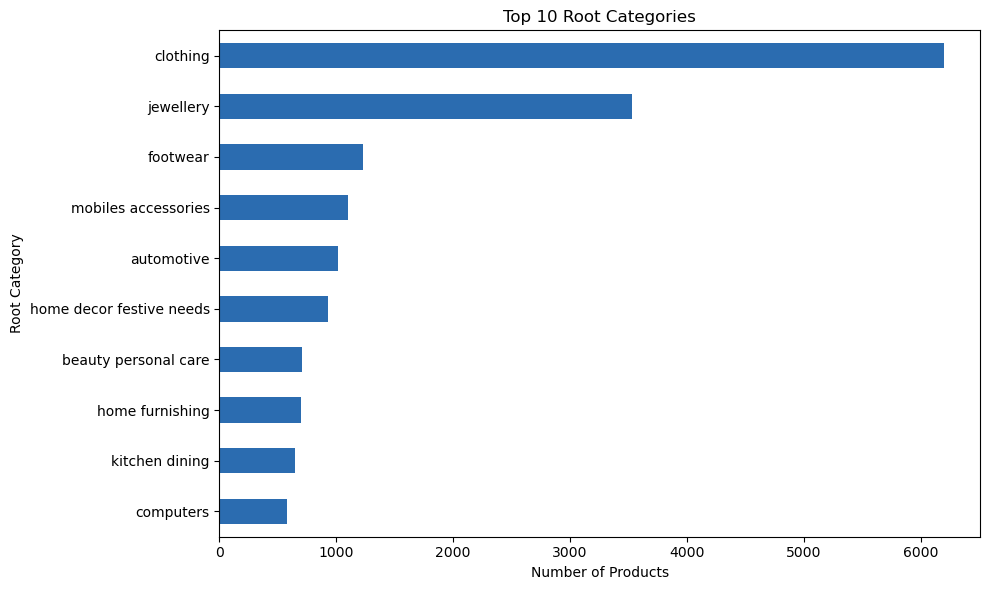

In [145]:
top_categories = clean_df['root_category'].value_counts().head(10).sort_values()
plt.figure(figsize=(10, 6))
top_categories.plot(kind='barh', color='#2b6cb0')
plt.title('Top 10 Root Categories')
plt.xlabel('Number of Products')
plt.ylabel('Root Category')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'top_categories.png', dpi=300)
plt.show()

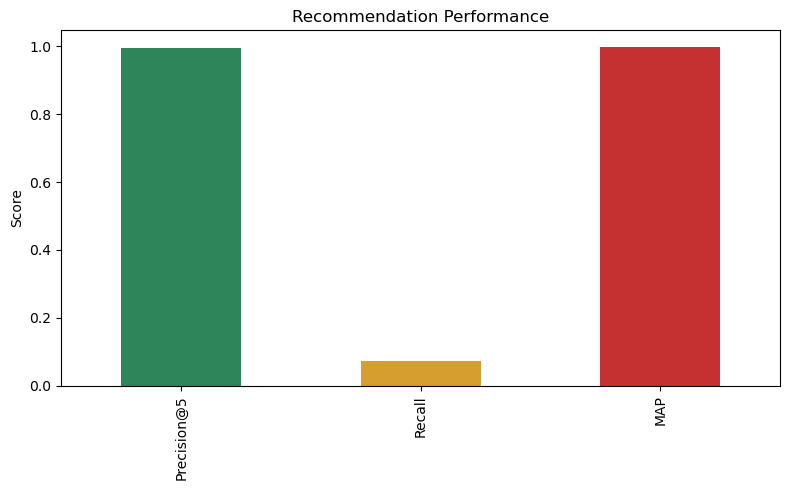

In [146]:
metric_series = metrics.iloc[0][['Precision@5', 'Recall', 'MAP']]
plt.figure(figsize=(8, 5))
metric_series.plot(kind='bar', color=['#2f855a', '#d69e2e', '#c53030'])
plt.title('Recommendation Performance')
plt.ylabel('Score')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'evaluation_metrics.png', dpi=300)
plt.show()

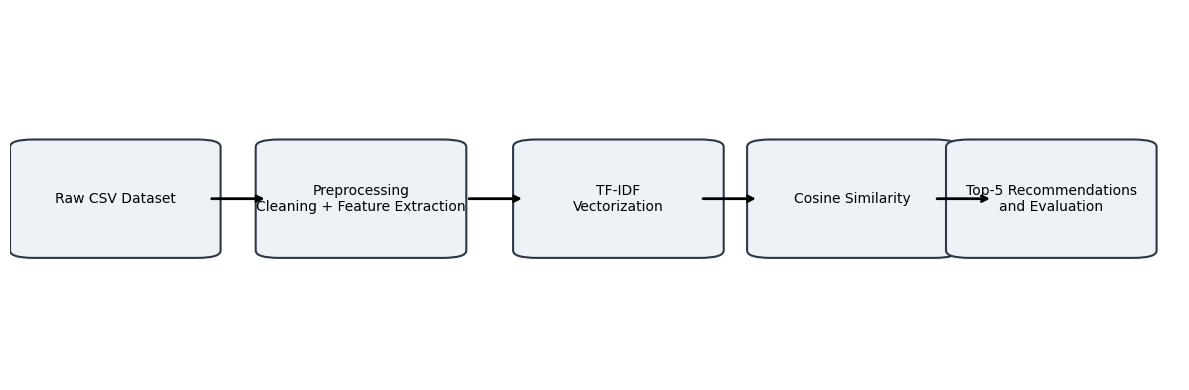

In [147]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')
steps = [
    'Raw CSV Dataset',
    'Preprocessing\nCleaning + Feature Extraction',
    'TF-IDF\nVectorization',
    'Cosine Similarity',
    'Top-5 Recommendations\nand Evaluation'
]
x_positions = [0.02, 0.23, 0.45, 0.65, 0.82]
for x_pos, label in zip(x_positions, steps):
    patch = FancyBboxPatch((x_pos, 0.35), 0.14, 0.28, boxstyle='round,pad=0.02',
                           facecolor='#edf2f7', edgecolor='#2d3748', linewidth=1.5)
    ax.add_patch(patch)
    ax.text(x_pos + 0.07, 0.49, label, ha='center', va='center', fontsize=10)
for arrow_x in [0.17, 0.39, 0.59, 0.79]:
    ax.annotate('', xy=(arrow_x + 0.05, 0.49), xytext=(arrow_x, 0.49), arrowprops=dict(arrowstyle='->', lw=2))
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'recommendation_pipeline.png', dpi=300)
plt.show()

## 9. Save Tables and Outputs

In [148]:
clean_df.to_csv(OUTPUT_DIR / 'cleaned_products.csv', index=False)
dataset_summary.to_csv(TABLE_DIR / 'dataset_summary.csv', index=False)
clean_df[['product_name', 'brand', 'root_category', 'leaf_category', 'retail_price', 'discounted_price']].head(10).to_csv(TABLE_DIR / 'sample_products.csv', index=False)
per_item_results.to_csv(TABLE_DIR / 'per_item_evaluation.csv', index=False)
metrics.to_csv(TABLE_DIR / 'evaluation_results.csv', index=False)
recommendations[['product_name', 'brand', 'root_category', 'leaf_category', 'discounted_price', 'cosine_score', 'hybrid_score', 'similarity_score', 'is_strong_match']].to_csv(TABLE_DIR / 'example_recommendations.csv', index=False)

print('All outputs saved under the outputs/ directory.')

All outputs saved under the outputs/ directory.
